In [17]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv('train1.csv', dtype={
 'HighBP': 'int',
 'HighChol': 'int',
 'CholCheck': 'int',
 'Smoker': 'int',
 'Stroke': 'int',
 'HeartDiseaseorAttack': 'int',
 'PhysActivity': 'int',
 'Fruits': 'int',
 'Veggies': 'int',
 'HvyAlcoholConsump': 'int',
 'AnyHealthcare': 'int',
 'NoDocbcCost':'int',
 'DiffWalk': 'int',
 'Sex': 'int'
 })
df
# sns.pairplot(data = df)
display(df['BMI'].describe())
df = df[df.duplicated() == False]
df.duplicated().sum()
df.head()
df.shape

,BMI
count,177576.000000
mean,28.648451
std,8.212638
min,10.000000
25%,24.000000
50%,27.000000
75%,31.000000
max,98.000000


(165299, 22)

In [58]:
examine = df.sample(3000, random_state=42)
df2 = pd.read_csv('test1.csv', dtype={
 'HighBP': 'int',
 'HighChol': 'int',
 'CholCheck': 'int',
 'Smoker': 'int',
 'Stroke': 'int',
 'HeartDiseaseorAttack': 'int',
 'PhysActivity': 'int',
 'Fruits': 'int',
 'Veggies': 'int',
 'HvyAlcoholConsump': 'int',
 'AnyHealthcare': 'int',
 'NoDocbcCost':'int',
 'DiffWalk': 'int',
 'Sex': 'int'
 })
examine2 = df2.sample(3000, random_state=4)
test_data_id = df2['row_id']
df2 = df2.drop(columns=['row_id'])
# sns.pairplot(data = examine) - Education == 0 is suspicious.
#sns.kdeplot(data = df, x= 'BMI', hue = 'Diabetes_binary') - No use
# for i in df.columns:
#     sns.histplot(data = df, x= i, hue = 'Diabetes_binary', kde=True)
#     plt.show()
#     plt.close()

# display(df2['BMI'].describe())
# df['BMI'].describe()

d = {i:np.sort(df[i].unique()) for i in df.columns}
d.pop('BMI')
d
df2.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,...,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000
mean,0.428821,0.423736,0.963340,28.396523,0.443209,0.041194,0.093609,0.755098,0.633055,0.811022,...,0.951461,0.083268,2.510788,3.165156,4.238581,0.169019,0.437178,8.033165,5.051995,6.054662
std,0.494911,0.494153,0.187928,6.610627,0.496768,0.198739,0.291286,0.430032,0.481975,0.391494,...,0.214903,0.276288,1.068247,7.379504,8.714505,0.374771,0.496041,3.063224,0.984801,2.066146
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [59]:
diabetes = df['Diabetes_binary'].sum()
# for i in df.columns:
#     if i == 'BMI':
#         continue
#     print(i)
#     for j in d[i]:
#         a = df[df[i] == j]
#         b = a['Diabetes_binary'].sum()

#         print(f"       {j} :\n       Probability of diabetes = {(b*100)/(a.shape[0])}       [[TD:{a.shape[0]} '+' :{b}]]\n       overall '+'ve contribution : {(b*100)/(diabetes)}")

In [22]:
# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[df['CholCheck'] == 0], x='HighChol', ax= ax[0])
# sns.countplot(data = df2[df2['CholCheck'] == 0], x='HighChol', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[df['DiffWalk'] == 1], x='PhysActivity', ax= ax[0])
# sns.countplot(data = df2[df2['DiffWalk'] == 1], x='PhysActivity', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2, figsize = (30, 10))
# sns.countplot(data = df[df['PhysActivity'] == 0], x='PhysHlth', ax= ax[0])
# sns.countplot(data = df2[df2['PhysActivity'] == 0], x='PhysHlth', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2, figsize = (30, 10))
# sns.countplot(data = df[(df['PhysHlth'] >15) & (df["MentHlth"] > 15)], x='GenHlth', ax= ax[0])
# sns.countplot(data = df2[(df2['PhysHlth'] >15) & (df2["MentHlth"] > 15)], x='GenHlth', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2, figsize = (30, 10))
# sns.countplot(data = df[(df['Fruits'] == 1) & (df['Veggies'] == 1)], x='GenHlth', ax= ax[0])
# sns.countplot(data = df2[(df2['Fruits'] == 1) & (df2['Veggies'] == 1)], x='GenHlth', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2, figsize = (30, 10))
# sns.countplot(data = df[df['HvyAlcoholConsump'] == 1], x='GenHlth', ax= ax[0])
# sns.countplot(data = df2[df2['HvyAlcoholConsump'] == 1], x='GenHlth', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2, figsize = (30, 20))
# sns.countplot(data = df[df['NoDocbcCost'] == 1], x='AnyHealthcare', ax= ax[0])
# sns.countplot(data = df2[df2['NoDocbcCost'] == 1], x='AnyHealthcare', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()


# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[df['HeartDiseaseorAttack'] == 1], x='HighBP', ax= ax[0])
# sns.countplot(data = df2[df2['HeartDiseaseorAttack'] == 1], x='HighBP', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[df['HeartDiseaseorAttack'] == 1], x='Stroke', ax= ax[0])
# sns.countplot(data = df2[df2['HeartDiseaseorAttack'] == 1], x='Stroke', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[df['Stroke'] == 1], x='HeartDiseaseorAttack', ax= ax[0])
# sns.countplot(data = df2[df2['Stroke'] == 1], x='HeartDiseaseorAttack', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[df['Smoker'] == 1], x='HeartDiseaseorAttack', ax= ax[0])
# sns.countplot(data = df2[df2['Smoker'] == 1], x='HeartDiseaseorAttack', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

In [23]:
# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[(df['Smoker'] == 1) & (df["HvyAlcoholConsump"] == 1)], x='HeartDiseaseorAttack', ax= ax[0])
# sns.countplot(data = df2[(df2['Smoker'] == 1) & (df2["HvyAlcoholConsump"] == 1)], x='HeartDiseaseorAttack', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[(df['Smoker'] == 1) & (df["HvyAlcoholConsump"] == 1)], x='GenHlth', ax= ax[0])
# sns.countplot(data = df2[(df2['Smoker'] == 1) & (df2["HvyAlcoholConsump"] == 1)], x='GenHlth', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()



# fig, ax = plt.subplots(1, 2, figsize= (40, 20))
# sns.countplot(data = df, x='Income', hue='Education', ax= ax[0])
# sns.countplot(data = df2, x='Income',hue = 'Education', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

# fig, ax = plt.subplots(1, 2)
# sns.boxplot(data = df, y='Income', x='Education', ax= ax[0])
# sns.boxplot(data = df2, y='Income',x = 'Education', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

In [24]:
# fig, ax = plt.subplots(1, 2)
# sns.countplot(data = df[(df['Fruits'] == 1) & (df["Veggies"] == 1)], x='Income', ax= ax[0])
# sns.countplot(data = df2[(df2['Fruits'] == 1) & (df2["Veggies"] == 1)], x='Income', ax= ax[1])
# plt.tight_layout()
# plt.show()
# plt.close()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,...,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.00000,162697.000000
mean,0.448109,0.437642,0.959858,29.195396,0.460340,0.043234,0.101114,0.740204,0.618198,0.799652,...,0.091016,2.578142,3.794557,4.893833,0.180304,0.441170,8.070382,4.997474,5.93172,0.187944
std,0.497302,0.496098,0.196293,8.114601,0.498426,0.203383,0.301481,0.438524,0.485830,0.400262,...,0.287632,1.065026,8.237863,9.395784,0.384442,0.496528,3.082286,0.990985,2.08852,0.390669
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.00000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.00000,0.000000
75%,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.00000,0.000000
max,1.000000,1.000000,1.000000,95.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.00000,1.000000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,...,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000
mean,0.428821,0.423736,0.963340,28.396523,0.443209,0.041194,0.093609,0.755098,0.633055,0.811022,...,0.951461,0.083268,2.510788,3.165156,4.238581,0.169019,0.437178,8.033165,5.051995,6.054662
std,0.494911,0.494153,0.187928,6.610627,0.496768,0.198739,0.291286,0.430032,0.481975,0.391494,...,0.214903,0.276288,1.068247,7.379504,8.714505,0.374771,0.496041,3.063224,0.984801,2.066146
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


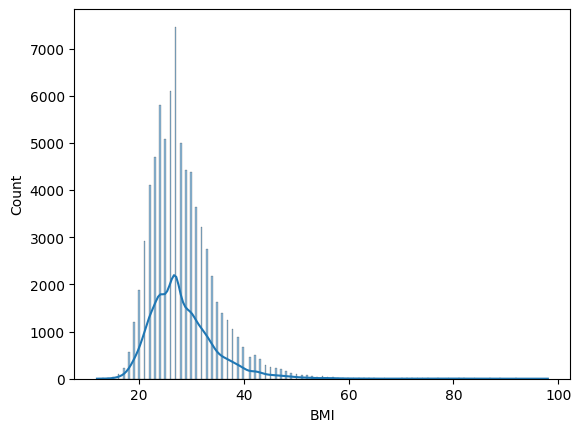

In [60]:
sns.histplot(data = df2, x = 'BMI', kde = True)
df = df[(df['BMI'] >= 12) & (df['BMI'] <= 95) ]
display(df.describe())
display(df2.describe())
#df.isna().sum()

In [61]:
df.info()
df
df['MentHlth'] = df['MentHlth']/30
df['PhysHlth'] = df['PhysHlth']/30
df['Income'] = (df['Income']-1)/(7)
df['Age'] = (df['Age']-1)/(12)
df['Education'] = (df['Education']-1)/(5)
df['GenHlth'] = (df['GenHlth'] -1)/4

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['BMI'] = scaler.fit_transform(df[['BMI']])
display(df.describe())
df2['MentHlth'] = df2['MentHlth']/30
df2['PhysHlth'] = df2['PhysHlth']/30
df2['Income'] = (df2['Income']-1)/(7)
df2['Age'] = (df2['Age']-1)/(12)
df2['Education'] = (df2['Education']-1)/(5)
df2['GenHlth'] = (df2['GenHlth'] -1)/4

df2['BMI'] = scaler.transform(df2[['BMI']])
display(df2.describe())








<class 'pandas.core.frame.DataFrame'>
Index: 162697 entries, 0 to 177574
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                162697 non-null  int64  
 1   HighChol              162697 non-null  int64  
 2   CholCheck             162697 non-null  int64  
 3   BMI                   162697 non-null  float64
 4   Smoker                162697 non-null  int64  
 5   Stroke                162697 non-null  int64  
 6   HeartDiseaseorAttack  162697 non-null  int64  
 7   PhysActivity          162697 non-null  int64  
 8   Fruits                162697 non-null  int64  
 9   Veggies               162697 non-null  int64  
 10  HvyAlcoholConsump     162697 non-null  int64  
 11  AnyHealthcare         162697 non-null  int64  
 12  NoDocbcCost           162697 non-null  int64  
 13  GenHlth               162697 non-null  float64
 14  MentHlth              162697 non-null  int64  
 15  PhysH

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,162697.000000,162697.000000,162697.000000,1.626970e+05,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,...,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000,162697.000000
mean,0.448109,0.437642,0.959858,9.519352e-16,0.460340,0.043234,0.101114,0.740204,0.618198,0.799652,...,0.091016,0.394536,0.126485,0.163128,0.180304,0.441170,0.589199,0.799495,0.704531,0.187944
std,0.497302,0.496098,0.196293,1.000003e+00,0.498426,0.203383,0.301481,0.438524,0.485830,0.400262,...,0.287632,0.266256,0.274595,0.313193,0.384442,0.496528,0.256857,0.198197,0.298360,0.390669
min,0.000000,0.000000,0.000000,-2.119075e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,-6.402548e-01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.416667,0.600000,0.571429,0.000000
50%,0.000000,0.000000,1.000000,-2.705497e-01,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.583333,0.800000,0.714286,0.000000
75%,1.000000,1.000000,1.000000,3.456254e-01,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.500000,0.066667,0.133333,0.000000,1.000000,0.750000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,8.109432e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,...,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000,76104.000000
mean,0.428821,0.423736,0.963340,-0.098449,0.443209,0.041194,0.093609,0.755098,0.633055,0.811022,...,0.951461,0.083268,0.377697,0.105505,0.141286,0.169019,0.437178,0.586097,0.810399,0.722095
std,0.494911,0.494153,0.187928,0.814661,0.496768,0.198739,0.291286,0.430032,0.481975,0.391494,...,0.214903,0.276288,0.267062,0.245983,0.290483,0.374771,0.496041,0.255269,0.196960,0.295164
min,0.000000,0.000000,0.000000,-2.119075,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,-0.640255,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.416667,0.600000,0.571429
50%,0.000000,0.000000,1.000000,-0.270550,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.583333,0.800000,0.857143
75%,1.000000,1.000000,1.000000,0.222390,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,0.500000,0.066667,0.100000,0.000000,1.000000,0.750000,1.000000,1.000000
max,1.000000,1.000000,1.000000,8.479137,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [99]:
df = pd.read_csv('train_cleaned_CL2.csv')
# df = df.sort_values(by = 'row_id')
# df.set_index('row_id', inplace = True)
# df = df.reset_index()
# df = df.drop(columns = 'row_id')
df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,0,1,-0.640255,1,0,0,1,1,1,...,0,0.25,0.133333,0.000000,0,0,0.583333,0.8,0.857143,0.0
1,0,0,1,-0.147315,0,0,0,1,1,1,...,0,0.25,0.233333,0.000000,0,0,0.416667,0.6,1.000000,0.0
2,1,0,1,-0.270550,0,0,0,1,1,1,...,0,0.00,0.000000,0.000000,0,1,0.500000,1.0,1.000000,0.0
3,0,0,1,-0.886725,1,0,0,1,1,1,...,0,0.25,0.000000,0.000000,0,0,0.500000,0.6,1.000000,0.0
4,1,0,1,0.222390,1,0,0,1,0,1,...,0,0.50,0.133333,0.000000,0,1,0.500000,0.8,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120491,0,0,1,0.222390,1,0,0,1,1,1,...,0,1.00,1.000000,1.000000,1,0,0.333333,0.8,0.714286,0.0
120492,0,0,1,0.715331,0,0,0,1,1,1,...,0,0.25,0.000000,0.033333,0,0,0.583333,1.0,1.000000,0.0
120493,0,0,1,-1.133195,1,0,0,0,1,1,...,0,0.25,0.333333,0.000000,0,0,0.500000,0.6,1.000000,0.0
120494,0,0,1,-1.256430,1,0,0,1,1,1,...,1,0.50,1.000000,0.066667,0,1,0.000000,0.6,1.000000,0.0


In [27]:
# a1['Diabetes_binary'] = y_pred
# a1
# b_df = pd.concat([b, a1], axis = 0)
# b_df['row_id'] = b_df.index
# b_df.to_csv('train_without_up_cleaned_1889.csv',index = False)

In [100]:
from enum import auto
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


# X_train = df.drop('Diabetes_binary', axis=1)
# X_test = df2.copy()
# y_train = df['Diabetes_binary']
# y_train = pd.get_dummies(y_train, dtype = int).values

# model  = Sequential()

# model.add(Input(shape=(X_train.shape[1],)))
# model.add(Dropout(0.4))

# model.add(Dense(256, input_dim=21, activation='relu'))
# model.add(Dropout(0.4))

# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))

# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.2))

# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.2))

# model.add(Dense(16, activation='relu'))
# model.add(Dropout(0.2))

# model.add(Dense(2, activation='softmax'))

# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy', keras.metrics.F1Score(average='macro', name = 'macro_f1')])

callback = EarlyStopping(
    monitor = 'val_macro_f1',
    min_delta = 0.00001,
    patience = 5,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights = True
)

In [101]:
df
# Model Data Using SMOTE, oversampling, undersampling
# df['Diabetes_binary'].value_counts()
# df_majority = df[df['Diabetes_binary'] == 0]
# df_minority = df[df['Diabetes_binary'] == 1]

# df_minority = df_minority.sample(132119, replace = True)
# df_minority.shape

# df_upsampled = pd.concat([df_majority, df_minority])
# df_upsampled['Diabetes_binary'].value_counts()
# df_upsampled.describe()

# X_train = df_upsampled.drop('Diabetes_binary', axis=1)
# y_train = df_upsampled['Diabetes_binary']
# y_train = pd.get_dummies(y_train, dtype = int).values

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, stratify = df['Diabetes_binary'], random_state=42)
df_0 = train_df[train_df['Diabetes_binary'] == 0]
df_1 = train_df[train_df['Diabetes_binary'] == 1]

# df_1 = df_1.sample(len(df_0), replace = True, random_state = 42)

train_df = pd.concat([df_0, df_1])
train_df = train_df.sample(frac= 1, random_state = 40)
# train_df['row_id'] = train_df.index
# train_df.to_csv('train_NN_0p6.csv', index = False)
# train_df = train_df.drop(columns = ['row_id'])

X_train = train_df.drop('Diabetes_binary', axis=1)
y_train = train_df['Diabetes_binary']
y_train = pd.get_dummies(y_train, dtype = int).values

X_test = val_df.drop('Diabetes_binary', axis=1)
y_test = val_df['Diabetes_binary']
y_test = pd.get_dummies(y_test, dtype = int).values

In [102]:
pip install -U keras-tuner

In [103]:
import keras_tuner as kt

In [105]:
def build_model(hp):
    model = keras.Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dropout(hp.Choice('dp0', values = [0.1, 0.2, 0.3,0.4,0.5,0.6])))

    for i in range(hp.Int('num_layers', 1, 20)):
        model.add(Dense(units=hp.Int('unit' + str(i),
                                      min_value=8,
                                      max_value=512,
                                      step=8),
                                      activation='relu'))
        model.add(Dropout(hp.Choice('dp' + str(i), values = [0.1, 0.2, 0.3,0.4,0.5,0.6])))

    model.add(Dense(2, activation='softmax'))
    optimizer = hp.Choice('optimizer', values=['sgd'])

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy', keras.metrics.F1Score(average='macro', name = 'macro_f1')])
    return model

tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective('val_macro_f1', direction = 'max'),
    max_trials=5,
    directory='my_dir',
    project_name='my_project3'
)

weights = {
    0 : 1.0,
    1 : 4.0
}
tuner.search(X_train, y_train, epochs=3, class_weight = weights, validation_data = (X_test, y_test))


Trial 4 Complete [00h 02m 56s]
val_macro_f1: 0.7592779397964478

Best val_macro_f1 So Far: 0.8859701156616211
Total elapsed time: 00h 08m 34s

Search: Running Trial #5

Value             |Best Value So Far |Hyperparameter
0.5               |0.1               |dp0
20                |11                |num_layers
408               |104               |unit0
sgd               |sgd               |optimizer
408               |8                 |unit1
0.6               |0.1               |dp1
96                |8                 |unit2
0.3               |0.1               |dp2
240               |8                 |unit3
0.1               |0.1               |dp3
72                |8                 |unit4
0.3               |0.1               |dp4
128               |8                 |unit5
0.4               |0.1               |dp5
448               |8                 |unit6
0.1               |0.1               |dp6
440               |8                 |unit7
0.6               |0.1             

KeyboardInterrupt: 

In [106]:
tuner.get_best_hyperparameters()[0].values

{'dp0': 0.1,
 'num_layers': 11,
 'unit0': 104,
 'optimizer': 'sgd',
 'unit1': 8,
 'dp1': 0.1,
 'unit2': 8,
 'dp2': 0.1,
 'unit3': 8,
 'dp3': 0.1,
 'unit4': 8,
 'dp4': 0.1,
 'unit5': 8,
 'dp5': 0.1,
 'unit6': 8,
 'dp6': 0.1,
 'unit7': 8,
 'dp7': 0.1,
 'unit8': 8,
 'dp8': 0.1,
 'unit9': 8,
 'dp9': 0.1,
 'unit10': 8,
 'dp10': 0.1}

In [107]:
model = tuner.get_best_models(num_models = 1)[0]
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 104)            │         2,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 104)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,794 (14.82 KB)

 Trainable params: 3,794 (14.82 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
history = model.fit(X_train, y_train, epochs = 100, initial_epoch = 1, class_weight = weights, validation_data = (X_test, y_test), callbacks = callback)

Epoch 2/100
3013/3013 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8685 - loss: 0.5751 - macro_f1: 0.7967 - val_accuracy: 0.9228 - val_loss: 0.2867 - val_macro_f1: 0.8703
Epoch 3/100
3013/3013 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8719 - loss: 0.5582 - macro_f1: 0.8009 - val_accuracy: 0.9381 - val_loss: 0.2295 - val_macro_f1: 0.8834
Epoch 4/100
3013/3013 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8742 - loss: 0.5441 - macro_f1: 0.8046 - val_accuracy: 0.9387 - val_loss: 0.2276 - val_macro_f1: 0.8818
Epoch 5/100
3013/3013 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.8707 - loss: 0.5483 - macro_f1: 0.8007 - val_accuracy: 0.9404 - val_loss: 0.2223 - val_macro_f1: 0.8864
Epoch 6/100
3013/3013 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8748 - loss: 0.5369 - macro_f1: 0.8054 - val_accuracy: 0.9424 - val_loss: 0.2390 - val_macro_f1: 0.8906
Epoch 7/100
3013/3013 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8777 - loss: 0.5322 - macro_f1: 0.8086 - val_accuracy: 0.939

2379/2379 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


,row_id,Diabetes_binary
count,76104.00000,76104.000000
mean,38051.50000,0.271957
std,21969.47678,0.444971
min,0.00000,0.000000
25%,19025.75000,0.000000
50%,38051.50000,0.000000
75%,57077.25000,1.000000
max,76103.00000,1.000000


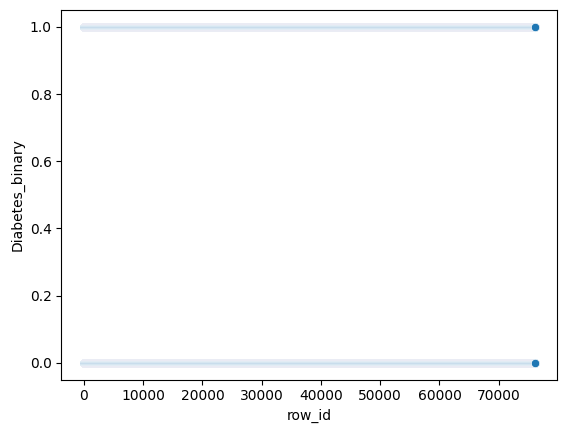

In [109]:
X_test = df2.copy()
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)
test_predictions = y_pred
test_data_id = df2.index

# Create the submission dataframe
submission = pd.DataFrame({
    'row_id': test_data_id,
    'Diabetes_binary': test_predictions
})

# Display the first few rows of the submission
display(submission.describe())
sns.scatterplot(data = submission, x = 'row_id', y = 'Diabetes_binary')
plt.show()
plt.close()



# Export to CSV (without the pandas index)
submission.to_csv('hack2.csv', index=False)

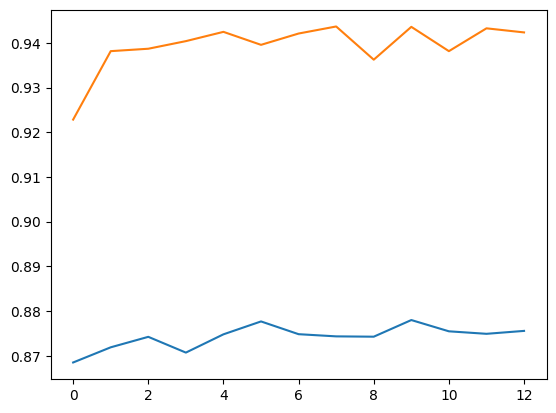

In [110]:
plt.plot(history.history['accuracy'], label = 'train')
plt.plot(history.history['val_accuracy'], label = 'test')

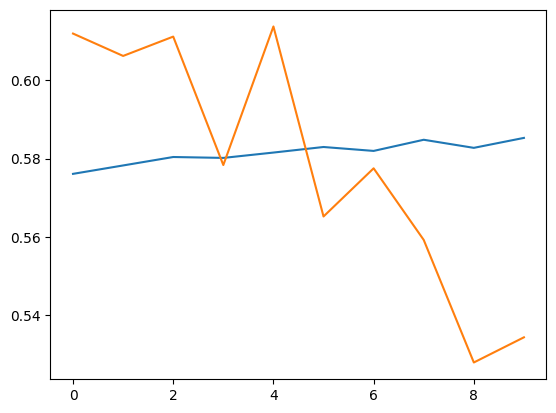

In [39]:
plt.plot(history.history['macro_f1'], label = 'train')
plt.plot(history.history['val_macro_f1'], label = 'test')

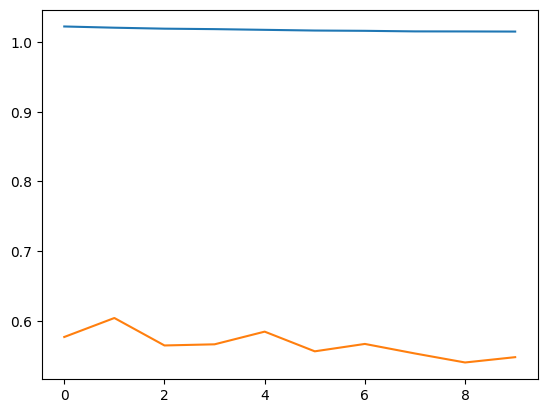

In [40]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')

In [ ]:
# import pandas as pd
# df = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/diabetes1/train1.csv')
# df2 = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/diabetes1/test1.csv')

In [ ]:


# b_df = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/diabetes/train_without_up_cleaned_1889.csv')
# b_df = b_df.sort_values(by = 'row_id')
# b_df.set_index('row_id', inplace=True)
# p = (df.index == b_df['row_id'])


# p = pd.DataFrame({
#     'row_id' : p
# })
# p.value_counts()

# print(df.shape[0])
# print(b_df.shape[0])
# df['Diabetes_binary'] = b_df['Diabetes_binary']
# print(df['Diabetes_binary'].isna().sum())
# from sklearn.impute import KNNImputer
# knn = KNNImputer(n_neighbors=1, weights='distance')

# knn.fit()
# X_test1['Rented_Bike_Count'] = np.nan
# X_test1[X_test.columns] = X_test[X_test.columns]
# X_test1 = knn.transform(X_test1)

# X_test1 = pd.DataFrame(X_test1, columns = X_train1.columns)
# display(X_test1)






# df.duplicated().sum()
# df = df[df.duplicated() == False]
# df.duplicated().sum()
# df.drop(columns = ['Diabetes_binary']).duplicated().sum()
# df1 = df.drop(columns = 'Diabetes_binary')

# print(b_df.isna().sum())
# print(df.isna().sum())



In [ ]:
# test = pd.read_csv('/kaggle/input/datasets/vamsiadithyayarru/diabetes1/test1.csv')

# test = test.drop(columns = ['row_id'])
# test.duplicated().sum()
# test = test[test.duplicated() == False]
# test.duplicated().sum()
# test = test[test.duplicated() == False]



# dup = pd.concat([df1, test], axis = 0)
# dup.duplicated().sum()
# d = dup.duplicated()
# a = d[d.shape[0]- test.shape[0]:d.shape[0]]
# a = a[a == True]
# a.value_counts()

# test_index = a.index
# test
# test = test.loc[test_index]
# test

# test['MentHlth'] = test['MentHlth']/30
# test['PhysHlth'] = test['PhysHlth']/30
# test['Income'] = (test['Income']-1)/(7)
# test['Age'] = (test['Age']-1)/(12)
# test['Education'] = (test['Education']-1)/(5)
# test['GenHlth'] = (test['GenHlth'] -1)/4

# test['BMI'] = scaler.transform(test[['BMI']])

# test

# df.isna().sum()



In [ ]:
# b1 = df.drop(columns = ['Diabetes_binary'])
# b2 = df['Diabetes_binary']
# a1 = test.copy()

# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# knn = KNeighborsClassifier(n_neighbors= 5, metric = 'euclidean')

# df_0 = df[df['Diabetes_binary'] == 0]
# df_1 = df[df['Diabetes_binary'] == 1]

# df_1 = df_1.sample(len(df_0), replace = True, random_state = 42)

# train_df = pd.concat([df_0, df_1])
# train_df = train_df.sample(frac= 1, random_state = 42)


# b1 = train_df.drop('Diabetes_binary', axis=1)#df.drop('Diabetes_binary', axis=1)
# b2 = train_df['Diabetes_binary'] #df['Diabetes_binary']


# a1 = test.copy()



# knn.fit(b1, b2)
# y_pred = knn.predict(a1)


# q = pd.DataFrame(y_pred, columns = ['Diabetes_binary'])
# display(q.value_counts())


In [ ]:
# submission1 = pd.DataFrame({
#     'row_id': a1.index,
#     'Diabetes_binary': y_pred
# })

# submission1.to_csv('dup1_1380_new.csv', index=False)






In [63]:
X_train = df.drop('Diabetes_binary', axis=1).copy()
y_prob = model.predict(X_train)
y_prob = pd.DataFrame({
    '0' : y_prob[:,0],
    '1' : y_prob[:,1]
}, index = df.index)

df = pd.concat([df, y_prob], axis = 1)
df.to_csv('train_cleaned_CL.csv', index = False)

5085/5085 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


In [84]:
df
df_0 = df[df['Diabetes_binary'] == 0]
df_1 = df[df['Diabetes_binary'] == 1]

t1 = (df_1['1'].sum())/(df_1['1'].count())
t0 = (df_0['0'].sum())/(df_0['0'].count())



In [85]:
k1 = df_1[df_1['0'] > t0]['0'].index
k1

Index([     3,    114,    117,    131,    134,    141,    160,    205,    214,
          235,
       ...
       177341, 177344, 177364, 177382, 177388, 177403, 177415, 177446, 177518,
       177533],
      dtype='int64', length=8527)

In [87]:
df_1

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,0,1
3,1,0,1,-0.270550,0,0,0,1,1,1,...,0.000000,0.000000,0,0,1.000000,0.8,0.428571,1.0,0.621188,0.378812
26,1,1,1,-0.024080,1,0,0,1,1,1,...,0.000000,0.000000,0,1,0.583333,0.8,0.857143,1.0,0.513420,0.486580
29,1,0,1,1.085036,0,0,0,1,1,1,...,0.000000,0.000000,0,0,0.916667,1.0,0.714286,1.0,0.506112,0.493888
41,0,0,1,0.838566,0,0,0,1,0,1,...,0.000000,0.066667,1,1,0.750000,0.6,0.571429,1.0,0.511366,0.488634
43,1,1,1,2.317386,1,0,0,1,0,1,...,0.000000,0.500000,1,0,0.666667,0.4,0.000000,1.0,0.382471,0.617529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177531,0,0,1,0.961801,1,0,0,0,0,1,...,0.000000,0.000000,0,1,0.833333,1.0,0.857143,1.0,0.525762,0.474238
177533,0,1,1,-0.517020,0,0,0,1,1,1,...,0.000000,0.000000,0,0,0.666667,1.0,1.000000,1.0,0.663357,0.336643
177555,0,0,1,0.961801,0,0,0,0,1,1,...,0.000000,0.000000,0,0,0.500000,0.8,0.857143,1.0,0.583383,0.416617
177558,1,1,1,-0.024080,1,0,0,0,0,0,...,0.000000,1.000000,0,1,0.750000,1.0,1.000000,1.0,0.484641,0.515359


In [88]:
df_1 = df_1.drop(k1)
df_1

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,0,1
26,1,1,1,-0.024080,1,0,0,1,1,1,...,0.000000,0.000000,0,1,0.583333,0.8,0.857143,1.0,0.513420,0.486580
29,1,0,1,1.085036,0,0,0,1,1,1,...,0.000000,0.000000,0,0,0.916667,1.0,0.714286,1.0,0.506112,0.493888
41,0,0,1,0.838566,0,0,0,1,0,1,...,0.000000,0.066667,1,1,0.750000,0.6,0.571429,1.0,0.511366,0.488634
43,1,1,1,2.317386,1,0,0,1,0,1,...,0.000000,0.500000,1,0,0.666667,0.4,0.000000,1.0,0.382471,0.617529
71,1,1,1,0.838566,0,0,0,0,1,0,...,0.000000,0.000000,0,1,0.833333,0.6,1.000000,1.0,0.509623,0.490377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177527,1,1,1,1.208271,0,0,0,1,0,1,...,0.133333,0.000000,1,0,0.666667,0.8,0.857143,1.0,0.435850,0.564150
177531,0,0,1,0.961801,1,0,0,0,0,1,...,0.000000,0.000000,0,1,0.833333,1.0,0.857143,1.0,0.525762,0.474238
177555,0,0,1,0.961801,0,0,0,0,1,1,...,0.000000,0.000000,0,0,0.500000,0.8,0.857143,1.0,0.583383,0.416617
177558,1,1,1,-0.024080,1,0,0,0,0,0,...,0.000000,1.000000,0,1,0.750000,1.0,1.000000,1.0,0.484641,0.515359


In [76]:
t0

np.float64(0.5898358558382973)

In [94]:
k0 = df_0[df_0['1'] > t1]['1'].index

In [95]:
df_0 = df_0.drop(k0)
df_0

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,0,1
0,0,0,1,-0.640255,1,0,0,1,1,1,...,0.133333,0.000000,0,0,0.583333,0.8,0.857143,0.0,0.663357,0.336643
1,0,0,1,-0.147315,0,0,0,1,1,1,...,0.233333,0.000000,0,0,0.416667,0.6,1.000000,0.0,0.663357,0.336643
4,1,0,1,-0.270550,0,0,0,1,1,1,...,0.000000,0.000000,0,1,0.500000,1.0,1.000000,0.0,0.630732,0.369268
6,0,0,1,-0.886725,1,0,0,1,1,1,...,0.000000,0.000000,0,0,0.500000,0.6,1.000000,0.0,0.663357,0.336643
7,1,0,1,0.222390,1,0,0,1,0,1,...,0.133333,0.000000,0,1,0.500000,0.8,1.000000,0.0,0.552298,0.447702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177569,0,0,1,0.222390,1,0,0,1,1,1,...,1.000000,1.000000,1,0,0.333333,0.8,0.714286,0.0,0.536344,0.463656
177570,0,0,1,0.715331,0,0,0,1,1,1,...,0.000000,0.033333,0,0,0.583333,1.0,1.000000,0.0,0.630850,0.369150
177572,0,0,1,-1.133195,1,0,0,0,1,1,...,0.333333,0.000000,0,0,0.500000,0.6,1.000000,0.0,0.663357,0.336643
177573,0,0,1,-1.256430,1,0,0,1,1,1,...,1.000000,0.066667,0,1,0.000000,0.6,1.000000,0.0,0.663357,0.336643


In [96]:
df_0 = df_0.drop(columns = ['0', '1'])
df_1 = df_1.drop(columns = ['0', '1'])
df = pd.concat([df_0, df_1], axis = 0)
df = df.sort_index()
df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,0,1,-0.640255,1,0,0,1,1,1,...,0,0.25,0.133333,0.000000,0,0,0.583333,0.8,0.857143,0.0
1,0,0,1,-0.147315,0,0,0,1,1,1,...,0,0.25,0.233333,0.000000,0,0,0.416667,0.6,1.000000,0.0
4,1,0,1,-0.270550,0,0,0,1,1,1,...,0,0.00,0.000000,0.000000,0,1,0.500000,1.0,1.000000,0.0
6,0,0,1,-0.886725,1,0,0,1,1,1,...,0,0.25,0.000000,0.000000,0,0,0.500000,0.6,1.000000,0.0
7,1,0,1,0.222390,1,0,0,1,0,1,...,0,0.50,0.133333,0.000000,0,1,0.500000,0.8,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177569,0,0,1,0.222390,1,0,0,1,1,1,...,0,1.00,1.000000,1.000000,1,0,0.333333,0.8,0.714286,0.0
177570,0,0,1,0.715331,0,0,0,1,1,1,...,0,0.25,0.000000,0.033333,0,0,0.583333,1.0,1.000000,0.0
177572,0,0,1,-1.133195,1,0,0,0,1,1,...,0,0.25,0.333333,0.000000,0,0,0.500000,0.6,1.000000,0.0
177573,0,0,1,-1.256430,1,0,0,1,1,1,...,1,0.50,1.000000,0.066667,0,1,0.000000,0.6,1.000000,0.0


In [97]:
df.to_csv('train_cleaned_CL2.csv', index=False)

In [98]:
df.isna().sum()

,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0
Veggies,0
